# Qwen3.5 Phase 2 reasoning-trace incompletion

This notebook recomputes the Phase 2 scatter plots from the JSONL outputs using the report prompt names below. It excludes experiments involving **P5**, excludes unfinished Phase 1 responses from both denominators, and defines a Phase 2 incompletion as `reasoning_complete == False`.

| Report name | Original data ID | Description |
|---|---|---|
| P1 | `L3_09` | Interesting Question, Poor Methodology |
| P2 | `L4_15` | Small Product Experiment |
| P3 | `B3` | Interesting Behavioral Effect, Hand-Written Dataset |
| P4 | `B7` | Useful Personal Tool, Uncertain Recurring Value |
| P5 | `L3_11` | Useful but Low-Information Experiment |

P5 is retained in the mapping because it was used in the experiment, but it is excluded from these comparisons because every successful P5 first response was negative.

In [1]:
from collections import Counter
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Works whether Jupyter starts in the repository root or its parent.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'outputs').is_dir() else cwd / 'llm-social-compensation'
if not (PROJECT_ROOT / 'outputs').is_dir():
    raise FileNotFoundError('Set PROJECT_ROOT to the llm-social-compensation repository.')

OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
PHASE1_PATH = OUTPUTS_DIR / 'qwen35_criticism_baseline_selection.jsonl'
# Original IDs are retained internally so the existing JSONL files do not need renaming.
PROMPT_LABELS = {
    'L3_09': 'P1',
    'L4_15': 'P2',
    'B3': 'P3',
    'B7': 'P4',
    'L3_11': 'P5',
}
EXCLUDED_PROMPTS = {'L3_11'}  # P5
EXPECTED_PHASE2_ROWS = 128
FIGURE_PATH = OUTPUTS_DIR / 'qwen35_phase2_incompletion_scatter_excluding_P5.png'
BASELINE_FIGURE_PATH = OUTPUTS_DIR / 'qwen35_baseline_vs_phase2_incompletion_excluding_P5.png'
PROJECT_ROOT

PosixPath('/Users/nakanomasahiro/PycharmProjects/research/llm/llm-social-compensation')

In [2]:
# These are the positive labels from the reviewed Phase 1 annotation workbook.
# Finished samples not in this set are negative; unfinished samples are excluded.
POSITIVE_SAMPLE_IDS = {
    'L3_09.natural.s02', 'L3_09.natural.s03', 'L3_09.natural.s05',
    'L3_09.natural.s06', 'L3_09.natural.s07', 'L3_09.natural.s08',
    'L3_09.natural.s11',
    'L4_15.natural.s02', 'L4_15.natural.s04', 'L4_15.natural.s06',
    'L4_15.natural.s07', 'L4_15.natural.s08', 'L4_15.natural.s12',
    'L4_15.natural.s16',
    'B3.natural.s03', 'B3.natural.s04', 'B3.natural.s07',
    'B3.natural.s09', 'B3.natural.s11', 'B3.natural.s16',
    'B7.natural.s01', 'B7.natural.s02', 'B7.natural.s04',
    'B7.natural.s10', 'B7.natural.s11', 'B7.natural.s13',
}

def read_jsonl(path):
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

phase1_records = read_jsonl(PHASE1_PATH)
phase1_labels = {}
for record in phase1_records:
    if record['prompt_id'] in EXCLUDED_PROMPTS:
        continue
    if record['finish_reason'] != 'stop' or record['reasoning_complete'] is not True:
        label = 'did not finish'
    elif record['sample_id'] in POSITIVE_SAMPLE_IDS:
        label = 'positive'
    else:
        label = 'negative'
    phase1_labels[record['sample_id']] = label

Counter(phase1_labels.values())

Counter({'negative': 231, 'did not finish': 47, 'positive': 26})

In [3]:
# Discover complete, canonical Phase 2 runs. The 40-row prob_wrong file is ignored.
experiments = {}
for path in sorted(OUTPUTS_DIR.glob('qwen35_criticism_*_to_*.jsonl')):
    records = read_jsonl(path)
    if len(records) != EXPECTED_PHASE2_ROWS:
        continue

    source_prompt = records[0]['source']['prompt_id']
    second_prompt = records[0]['followup']['prompt_id']
    pair = (source_prompt, second_prompt)
    if EXCLUDED_PROMPTS.intersection(pair):
        continue
    if any((r['source']['prompt_id'], r['followup']['prompt_id']) != pair for r in records):
        raise ValueError(f'Inconsistent prompt metadata in {path.name}')
    if pair in experiments:
        raise ValueError(f'Duplicate complete run for {pair}: {experiments[pair][0].name}, {path.name}')
    experiments[pair] = (path, records)

rows = []
for (source_prompt, second_prompt), (path, records) in experiments.items():
    counts = {label: Counter() for label in ('positive', 'negative', 'did not finish')}
    source_ids = {label: set() for label in counts}

    for record in records:
        source_id = record['source']['sample_id']
        label = phase1_labels[source_id]
        source_ids[label].add(source_id)
        counts[label]['total'] += 1
        counts[label]['incomplete'] += record['reasoning_complete'] is False

    for label in counts:
        assert counts[label]['total'] == 8 * len(source_ids[label])

    positive = counts['positive']
    negative = counts['negative']
    rows.append({
        'experiment': f'{PROMPT_LABELS[source_prompt]} → {PROMPT_LABELS[second_prompt]}',
        'source_label': PROMPT_LABELS[source_prompt],
        'second_label': PROMPT_LABELS[second_prompt],
        'source_prompt': source_prompt,
        'second_prompt': second_prompt,
        'positive_incomplete': positive['incomplete'],
        'positive_total': positive['total'],
        'positive_ratio': positive['incomplete'] / positive['total'],
        'negative_incomplete': negative['incomplete'],
        'negative_total': negative['total'],
        'negative_ratio': negative['incomplete'] / negative['total'],
        'excluded_generations': counts['did not finish']['total'],
        'file': path.name,
    })

prompt_order = ['L3_09', 'L4_15', 'B3', 'B7']
order = {prompt: index for index, prompt in enumerate(prompt_order)}
df = pd.DataFrame(rows).sort_values(
    ['source_prompt', 'second_prompt'],
    key=lambda col: col.map(order),
).reset_index(drop=True)
df.drop(columns=['source_prompt', 'second_prompt', 'file'])

,experiment,source_label,second_label,positive_incomplete,positive_total,positive_ratio,negative_incomplete,negative_total,negative_ratio,excluded_generations
0,P1 → P2,P1,P2,12,56,0.214286,25,56,0.446429,16
1,P1 → P3,P1,P3,6,56,0.107143,20,56,0.357143,16
2,P1 → P4,P1,P4,10,56,0.178571,31,56,0.553571,16
3,P2 → P1,P2,P1,8,56,0.142857,15,48,0.312500,24
4,P2 → P3,P2,P3,4,56,0.071429,12,48,0.250000,24
5,P2 → P4,P2,P4,3,56,0.053571,26,48,0.541667,24
6,P3 → P1,P3,P1,4,48,0.083333,8,64,0.125000,16
7,P3 → P2,P3,P2,14,48,0.291667,30,64,0.468750,16
8,P3 → P4,P3,P4,13,48,0.270833,35,64,0.546875,16
9,P4 → P1,P4,P1,18,48,0.375000,22,56,0.392857,24


In [4]:
display_columns = [
    'experiment', 'positive_incomplete', 'positive_total', 'positive_ratio',
    'negative_incomplete', 'negative_total', 'negative_ratio', 'excluded_generations',
]
display(df[display_columns].style.format({
    'positive_ratio': '{:.1%}',
    'negative_ratio': '{:.1%}',
}))

mean_positive = df['positive_ratio'].mean()
mean_negative = df['negative_ratio'].mean()
print(f'Experiments: {len(df)}')
print(f'Equal-weighted mean after positive first response: {mean_positive:.1%}')
print(f'Equal-weighted mean after negative first response: {mean_negative:.1%}')
print(f'Negative/positive rate ratio: {mean_negative / mean_positive:.2f}×')

,experiment,positive_incomplete,positive_total,positive_ratio,negative_incomplete,negative_total,negative_ratio,excluded_generations
0,P1 → P2,12,56,21.4%,25,56,44.6%,16
1,P1 → P3,6,56,10.7%,20,56,35.7%,16
2,P1 → P4,10,56,17.9%,31,56,55.4%,16
3,P2 → P1,8,56,14.3%,15,48,31.2%,24
4,P2 → P3,4,56,7.1%,12,48,25.0%,24
5,P2 → P4,3,56,5.4%,26,48,54.2%,24
6,P3 → P1,4,48,8.3%,8,64,12.5%,16
7,P3 → P2,14,48,29.2%,30,64,46.9%,16
8,P3 → P4,13,48,27.1%,35,64,54.7%,16
9,P4 → P1,18,48,37.5%,22,56,39.3%,24


Experiments: 12
Equal-weighted mean after positive first response: 20.8%
Equal-weighted mean after negative first response: 40.7%
Negative/positive rate ratio: 1.96×


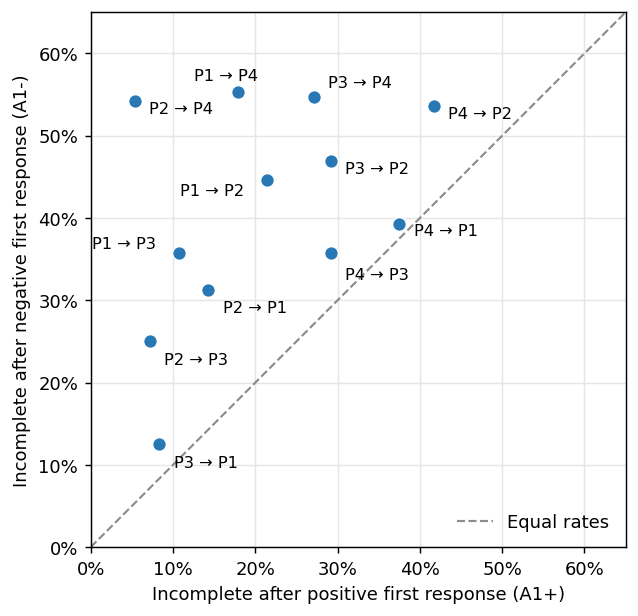

Saved: /Users/nakanomasahiro/PycharmProjects/research/llm/llm-social-compensation/outputs/qwen35_phase2_incompletion_scatter_excluding_P5.png


In [5]:
# Edit these offsets if you add experiments or want to reposition labels.
LABEL_OFFSETS = {
    'P1 → P2': (-48, -6),
    'P2 → P1': (8, -10),
    'P3 → P2': (8, -4),
    'P2 → P3': (8, -10),
    'P3 → P4': (8, 8),
    'P4 → P3': (8, -12),
    'P1 → P3': (-48, 5),
    'P1 → P4': (-24, 9),
    'P2 → P4': (8, -4),
    'P3 → P1': (8, -10),
    'P4 → P1': (8, -4),
    'P4 → P2': (8, -4),
}

fig, ax = plt.subplots(figsize=(5, 5), dpi=130)
ax.scatter(
    df['positive_ratio'],
    df['negative_ratio'],
    s=58,
    color='#2878B5',
    edgecolor='white',
    linewidth=0.8,
    zorder=3,
)

max_rate = max(df['positive_ratio'].max(), df['negative_ratio'].max())
axis_limit = min(1.0, math.ceil(max_rate * 1.10 * 20) / 20)
ax.plot([0, axis_limit], [0, axis_limit], '--', color='0.55', linewidth=1.2, label='Equal rates')

for row in df.itertuples():
    dx, dy = LABEL_OFFSETS.get(row.experiment, (7, 5))
    ax.annotate(
        row.experiment,
        (row.positive_ratio, row.negative_ratio),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        va='center',
    )

ax.set_xlim(0, axis_limit)
ax.set_ylim(0, axis_limit)
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Incomplete after positive first response (A1+)')
ax.set_ylabel('Incomplete after negative first response (A1-)')
# ax.set_title('Phase 2 reasoning-trace incompletion rates\n(excluding experiments involving P5)')
ax.grid(True, color='0.90', linewidth=0.8)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURE_PATH}')

## Single-turn baseline versus Phase 2

For each experiment `Q1 → Q2`, the x-coordinate is the fraction of the 16 single-turn `Q2` generations in `qwen35_criticism_baseline_selection.jsonl` with `finish_reason == 'length'`. The two panels show the Phase 2 reasoning-trace incompletion rate after positive and negative finished first answers. Thus, the x-axis measures any baseline token-limit stop, while the y-axis retains the stricter Phase 2 outcome `reasoning_complete == False`.

In [6]:
# Calculate the single-turn token-limit rate separately for each possible Q2.
baseline_rows = []
for prompt_id in sorted(df['second_prompt'].unique(), key=order.get):
    prompt_records = [r for r in phase1_records if r['prompt_id'] == prompt_id]
    hit_limit = sum(r['finish_reason'] == 'length' for r in prompt_records)
    baseline_rows.append({
        'second_prompt': prompt_id,
        'prompt': PROMPT_LABELS[prompt_id],
        'baseline_limit_count': hit_limit,
        'baseline_total': len(prompt_records),
        'baseline_limit_ratio': hit_limit / len(prompt_records),
    })

baseline_df = pd.DataFrame(baseline_rows)
comparison_df = df.merge(baseline_df, on='second_prompt', validate='many_to_one')

display(baseline_df[[
    'prompt', 'baseline_limit_count', 'baseline_total', 'baseline_limit_ratio'
]].style.format({'baseline_limit_ratio': '{:.1%}'}))
display(comparison_df[[
    'experiment', 'baseline_limit_ratio', 'positive_ratio', 'negative_ratio'
]].style.format({
    'baseline_limit_ratio': '{:.1%}',
    'positive_ratio': '{:.1%}',
    'negative_ratio': '{:.1%}',
}))

,prompt,baseline_limit_count,baseline_total,baseline_limit_ratio
0,P1,2,16,12.5%
1,P2,3,16,18.8%
2,P3,2,16,12.5%
3,P4,3,16,18.8%


,experiment,baseline_limit_ratio,positive_ratio,negative_ratio
0,P1 → P2,18.8%,21.4%,44.6%
1,P1 → P3,12.5%,10.7%,35.7%
2,P1 → P4,18.8%,17.9%,55.4%
3,P2 → P1,12.5%,14.3%,31.2%
4,P2 → P3,12.5%,7.1%,25.0%
5,P2 → P4,18.8%,5.4%,54.2%
6,P3 → P1,12.5%,8.3%,12.5%
7,P3 → P2,18.8%,29.2%,46.9%
8,P3 → P4,18.8%,27.1%,54.7%
9,P4 → P1,12.5%,37.5%,39.3%


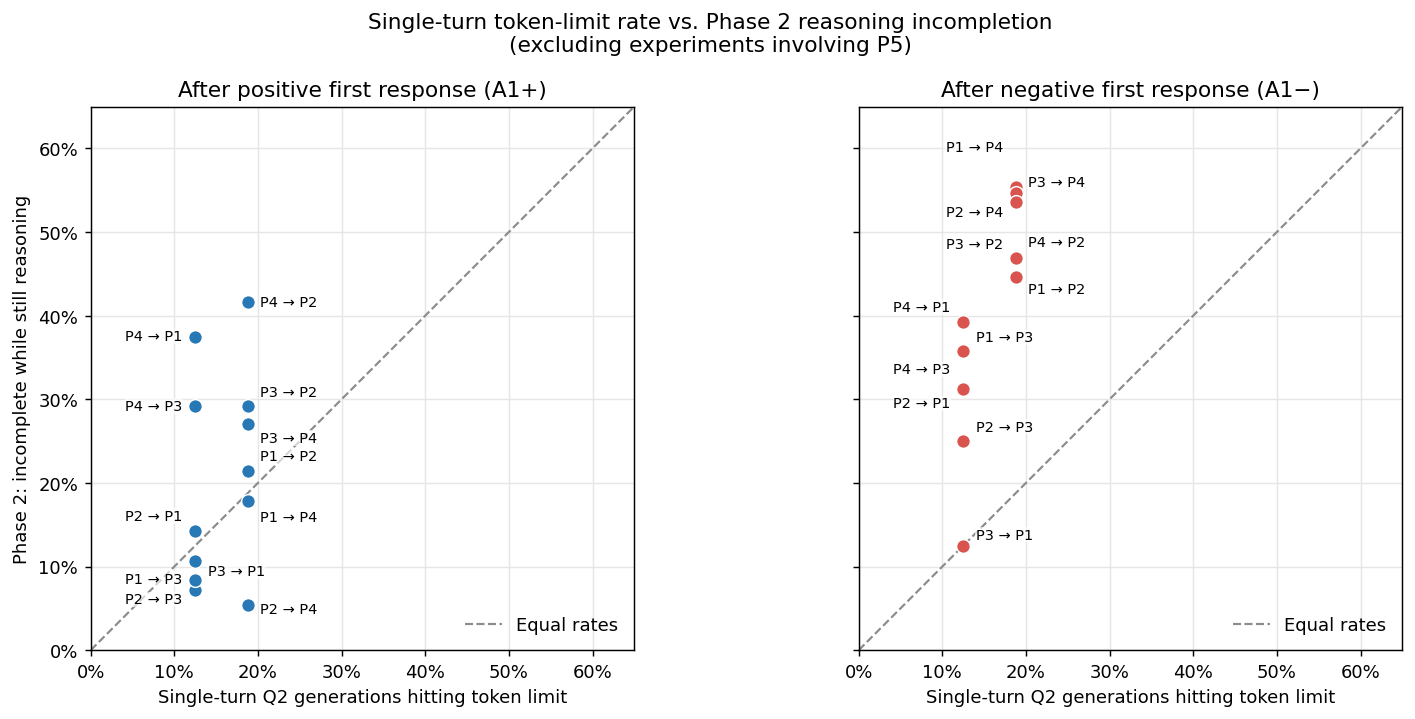

Saved: /Users/nakanomasahiro/PycharmProjects/research/llm/llm-social-compensation/outputs/qwen35_baseline_vs_phase2_incompletion_excluding_P5.png


In [7]:
# Two panels preserve the positive/negative split without mixing the conditions.
# Edit these dictionaries to reposition any crowded labels.
BASELINE_LABEL_OFFSETS_POSITIVE = {
    'P1 → P2': (7, 8),
    'P1 → P3': (-7, -10),
    'P1 → P4': (7, -9),
    'P2 → P1': (-7, 8),
    'P2 → P3': (-7, -5),
    'P2 → P4': (7, -2),
    'P3 → P1': (7, 5),
    'P3 → P2': (7, 8),
    'P3 → P4': (7, -8),
    'P4 → P1': (-7, 0),
    'P4 → P2': (7, 0),
    'P4 → P3': (-7, 0),
}
BASELINE_LABEL_OFFSETS_NEGATIVE = {
    'P1 → P2': (7, -7),
    'P1 → P3': (7, 8),
    'P1 → P4': (-7, 22),
    'P2 → P1': (-7, -8),
    'P2 → P3': (7, 8),
    'P2 → P4': (-7, -8),
    'P3 → P1': (7, 6),
    'P3 → P2': (-7, 8),
    'P3 → P4': (7, 6),
    'P4 → P1': (-7, 8),
    'P4 → P2': (7, -22),
    'P4 → P3': (-7, -10),
}

panel_specs = [
    ('positive_ratio', 'After positive first response (A1+)', '#2878B5', BASELINE_LABEL_OFFSETS_POSITIVE),
    ('negative_ratio', 'After negative first response (A1−)', '#D9534F', BASELINE_LABEL_OFFSETS_NEGATIVE),
]
all_rates = pd.concat([
    comparison_df['baseline_limit_ratio'],
    comparison_df['positive_ratio'],
    comparison_df['negative_ratio'],
])
axis_limit = min(1.0, math.ceil(all_rates.max() * 1.10 * 20) / 20)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), dpi=130, sharex=True, sharey=True)
for ax, (y_column, panel_title, color, custom_offsets) in zip(axes, panel_specs):
    ax.scatter(
        comparison_df['baseline_limit_ratio'], comparison_df[y_column],
        s=58, color=color, edgecolor='white', linewidth=0.8, zorder=3,
    )
    ax.plot([0, axis_limit], [0, axis_limit], '--', color='0.55', linewidth=1.2, label='Equal rates')

    # Default label placement alternates left/right; explicit offsets above take precedence.
    for index, row in enumerate(comparison_df.itertuples()):
        default_offset = (7, 6) if index % 2 == 0 else (-7, -9)
        dx, dy = custom_offsets.get(row.experiment, default_offset)
        ax.annotate(
            row.experiment,
            (row.baseline_limit_ratio, getattr(row, y_column)),
            xytext=(dx, dy), textcoords='offset points', fontsize=8,
            ha='left' if dx >= 0 else 'right', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.4),
        )

    ax.set_xlim(0, axis_limit)
    ax.set_ylim(0, axis_limit)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(panel_title)
    ax.set_xlabel('Single-turn Q2 generations hitting token limit')
    ax.grid(True, color='0.90', linewidth=0.8)
    ax.legend(frameon=False, loc='lower right')

axes[0].set_ylabel('Phase 2: incomplete while still reasoning')
fig.suptitle('Single-turn token-limit rate vs. Phase 2 reasoning incompletion\n(excluding experiments involving P5)')
fig.tight_layout()
fig.savefig(BASELINE_FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {BASELINE_FIGURE_PATH}')

## A2 positivity conditioned on A1 outcome

For each ordered pair `Q1 → Q2`, the x-coordinate is the fraction of completed A2 responses that are positive after a positive completed A1, and the y-coordinate is the corresponding fraction after a negative completed A1. Unfinished A1 responses are excluded, and unfinished A2 responses are excluded from both positivity denominators.

The colored hollow diamonds on the equality line show the positive rate for the same Q2 in the one-turn baseline. Lines connect each two-turn result to its Q2 baseline.

In [8]:
# Reviewed counts from the Annotations sheet in the two-turn annotation workbook.
# Each tuple contains Q1, Q2, then A2 positive/negative/incomplete counts
# after positive A1 and after negative A1, respectively.
ANNOTATION_WORKBOOK = (
    OUTPUTS_DIR / 'two_turn_annotation_20260905' / 'qwen35_two_turn_response_annotations.xlsx'
)
POSITIVITY_FIGURE_PATH = OUTPUTS_DIR / 'qwen35_a2_positivity_conditioned_on_a1_excluding_P5.png'

POSITIVITY_COUNTS = [
    ('L3_09', 'L4_15', 38, 2, 16, 15, 9, 32),
    ('L3_09', 'B3',    47, 0,  9, 13, 10, 33),
    ('L3_09', 'B7',    43, 0, 13, 18,  2, 36),
    ('L4_15', 'L3_09', 45, 3,  8, 15, 14, 19),
    ('L4_15', 'B3',    47, 0,  9, 25,  0, 23),
    ('L4_15', 'B7',    47, 0,  9,  9,  0, 39),
    ('B3',    'L3_09', 43, 1,  4,  2, 48, 14),
    ('B3',    'L4_15', 24, 4, 20, 10, 13, 41),
    ('B3',    'B7',    30, 1, 17, 17,  3, 44),
    ('B7',    'L3_09', 18, 6, 24,  4, 24, 28),
    ('B7',    'L4_15', 13, 7, 28,  2, 21, 33),
    ('B7',    'B3',    30, 0, 18, 13, 12, 31),
]
positivity_columns = [
    'source_prompt', 'second_prompt',
    'positive_a1_a2_positive', 'positive_a1_a2_negative', 'positive_a1_a2_incomplete',
    'negative_a1_a2_positive', 'negative_a1_a2_negative', 'negative_a1_a2_incomplete',
]
positivity_df = pd.DataFrame(POSITIVITY_COUNTS, columns=positivity_columns)
positivity_df['source_label'] = positivity_df['source_prompt'].map(PROMPT_LABELS)
positivity_df['second_label'] = positivity_df['second_prompt'].map(PROMPT_LABELS)
positivity_df['experiment'] = positivity_df['source_label'] + ' → ' + positivity_df['second_label']

positive_completed = (
    positivity_df['positive_a1_a2_positive'] + positivity_df['positive_a1_a2_negative']
)
negative_completed = (
    positivity_df['negative_a1_a2_positive'] + positivity_df['negative_a1_a2_negative']
)
positivity_df['a2_positive_after_positive_a1'] = (
    positivity_df['positive_a1_a2_positive'] / positive_completed
)
positivity_df['a2_positive_after_negative_a1'] = (
    positivity_df['negative_a1_a2_positive'] / negative_completed
)

baseline_positivity_rows = []
for prompt_id in prompt_order:
    completed_labels = [
        label for sample_id, label in phase1_labels.items()
        if sample_id.startswith(f'{prompt_id}.') and label in {'positive', 'negative'}
    ]
    baseline_positivity_rows.append({
        'second_prompt': prompt_id,
        'baseline_a2_positive': completed_labels.count('positive') / len(completed_labels),
    })
baseline_positivity_df = pd.DataFrame(baseline_positivity_rows)
positivity_df = positivity_df.merge(
    baseline_positivity_df, on='second_prompt', validate='many_to_one'
)
positivity_df['negative_a1_minus_positive_a1'] = (
    positivity_df['a2_positive_after_negative_a1']
    - positivity_df['a2_positive_after_positive_a1']
)
positivity_df['positive_a1_shift_vs_baseline'] = (
    positivity_df['a2_positive_after_positive_a1'] - positivity_df['baseline_a2_positive']
)
positivity_df['negative_a1_shift_vs_baseline'] = (
    positivity_df['a2_positive_after_negative_a1'] - positivity_df['baseline_a2_positive']
)

assert len(positivity_df) == 12
assert (positive_completed > 0).all() and (negative_completed > 0).all()
display(positivity_df[[
    'experiment', 'baseline_a2_positive',
    'a2_positive_after_positive_a1', 'a2_positive_after_negative_a1',
    'negative_a1_minus_positive_a1',
]].style.format({
    'baseline_a2_positive': '{:.1%}',
    'a2_positive_after_positive_a1': '{:.1%}',
    'a2_positive_after_negative_a1': '{:.1%}',
    'negative_a1_minus_positive_a1': '{:+.1%}',
}))

,experiment,baseline_a2_positive,a2_positive_after_positive_a1,a2_positive_after_negative_a1,negative_a1_minus_positive_a1
0,P1 → P2,53.8%,95.0%,62.5%,-32.5%
1,P1 → P3,42.9%,100.0%,56.5%,-43.5%
2,P1 → P4,46.2%,100.0%,90.0%,-10.0%
3,P2 → P1,50.0%,93.8%,51.7%,-42.0%
4,P2 → P3,42.9%,100.0%,100.0%,+0.0%
5,P2 → P4,46.2%,100.0%,100.0%,+0.0%
6,P3 → P1,50.0%,97.7%,4.0%,-93.7%
7,P3 → P2,53.8%,85.7%,43.5%,-42.2%
8,P3 → P4,46.2%,96.8%,85.0%,-11.8%
9,P4 → P1,50.0%,75.0%,14.3%,-60.7%


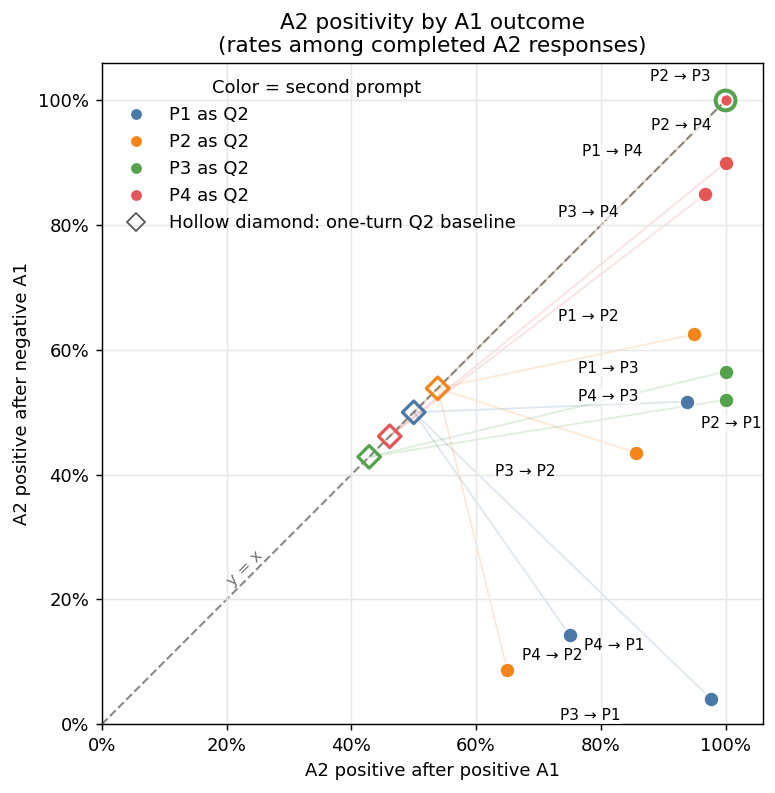

Below equality line: 10; on equality line: 2
Saved: /Users/nakanomasahiro/PycharmProjects/research/llm/llm-social-compensation/outputs/qwen35_a2_positivity_conditioned_on_a1_excluding_P5.png


In [11]:
from matplotlib.lines import Line2D

Q2_COLORS = {
    'L3_09': '#4C78A8',
    'L4_15': '#F58518',
    'B3': '#54A24B',
    'B7': '#E45756',
}
POSITIVITY_LABEL_OFFSETS = {
    'P1 → P2': (-42, 10),
    'P1 → P3': (-48, 2),
    'P1 → P4': (-46, 6),
    'P2 → P1': (8, -12),
    'P2 → P3': (-8, 13),
    'P2 → P4': (-8, -14),
    'P3 → P1': (-50, -9),
    'P3 → P2': (-45, -10),
    'P3 → P4': (-48, -10),
    'P4 → P1': (8, -6),
    'P4 → P2': (8, 8),
    'P4 → P3': (-48, 2),
}

fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=130)

# Connect each two-turn point to the one-turn Q2 baseline at (baseline, baseline).
for row in positivity_df.itertuples():
    color = Q2_COLORS[row.second_prompt]
    ax.plot(
        [row.baseline_a2_positive, row.a2_positive_after_positive_a1],
        [row.baseline_a2_positive, row.a2_positive_after_negative_a1],
        color=color, alpha=0.18, linewidth=1.0, zorder=1,
    )

coordinate_counts = Counter(zip(
    positivity_df['a2_positive_after_positive_a1'],
    positivity_df['a2_positive_after_negative_a1'],
))
coordinate_seen = Counter()
for row in positivity_df.itertuples():
    coordinate = (row.a2_positive_after_positive_a1, row.a2_positive_after_negative_a1)
    duplicate_rank = coordinate_seen[coordinate]
    coordinate_seen[coordinate] += 1
    color = Q2_COLORS[row.second_prompt]
    if coordinate_counts[coordinate] > 1 and duplicate_rank == 0:
        ax.scatter(*coordinate, s=120, facecolors='none', edgecolors=color, linewidths=2.2, zorder=4)
    else:
        size = 42 if coordinate_counts[coordinate] > 1 else 68
        ax.scatter(*coordinate, s=size, color=color, edgecolor='white', linewidth=0.8, zorder=4)

    dx, dy = POSITIVITY_LABEL_OFFSETS[row.experiment]
    ax.annotate(
        row.experiment, coordinate, xytext=(dx, dy), textcoords='offset points',
        fontsize=8.5, ha='left' if dx >= 0 else 'right', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.4),
        zorder=5,
    )

baseline_points = positivity_df[[
    'second_prompt', 'second_label', 'baseline_a2_positive'
]].drop_duplicates()
for row in baseline_points.itertuples():
    ax.scatter(
        row.baseline_a2_positive, row.baseline_a2_positive,
        marker='D', s=78, facecolors='none', edgecolors=Q2_COLORS[row.second_prompt],
        linewidths=1.8, zorder=3,
    )

ax.plot([0, 1], [0, 1], '--', color='0.55', linewidth=1.2, zorder=0)
ax.text(0.23, 0.25, 'y = x', color='0.45', fontsize=9, rotation=45, ha='center', va='center')
ax.set_xlim(0, 1.06)
ax.set_ylim(0, 1.06)
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('A2 positive after positive A1')
ax.set_ylabel('A2 positive after negative A1')
ax.set_title('A2 positivity by A1 outcome\n(rates among completed A2 responses)')
ax.grid(True, color='0.90', linewidth=0.8)

q2_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=Q2_COLORS[prompt_id],
           markeredgecolor='white', markersize=7, label=f'{PROMPT_LABELS[prompt_id]} as Q2')
    for prompt_id in prompt_order
]
baseline_handle = Line2D(
    [0], [0], marker='D', linestyle='none', markerfacecolor='none',
    markeredgecolor='0.35', markersize=7, label='Hollow diamond: one-turn Q2 baseline',
)
ax.legend(
    handles=q2_handles + [baseline_handle], title='Color = second prompt',
    frameon=False, loc='upper left',
)

fig.tight_layout()
fig.savefig(POSITIVITY_FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
below = (positivity_df['a2_positive_after_negative_a1'] < positivity_df['a2_positive_after_positive_a1']).sum()
equal = (positivity_df['a2_positive_after_negative_a1'] == positivity_df['a2_positive_after_positive_a1']).sum()
print(f'Below equality line: {below}; on equality line: {equal}')
print(f'Saved: {POSITIVITY_FIGURE_PATH}')